In [1]:
from pathlib import Path 
import os 
import sys
sys.path.insert(0, "../../../../../shared_utils")
from experiment_utils import manual_filtering

import matplotlib.pyplot as plt 
import scanpy as sc
import numpy as np 
import pandas as pd
import scipy as sp 
import seaborn as sns
from tqdm import tqdm 
import copy
import math
import yaml
import fpsample

## Read annotation file

In [2]:
# Annotation file for protocols 
ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

ANNOTATION_CFG_FILE_BOUNDS = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/constraints/default_all_cols.yaml"
with open(ANNOTATION_CFG_FILE_BOUNDS, "r") as fb:
    annotation_cfg_bound = yaml.safe_load(fb)
ubound_dict, lbound_dict = annotation_cfg_bound["ubound_dict"],  annotation_cfg_bound["lbound_dict"]

# Collect per parameter bounds 
bounds = {}
for param in lbound_dict:
    bounds[param] = (lbound_dict[param], ubound_dict[param])

### Collect optimized samples 

In [3]:
# path_to_results = Path("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/bloodplus_inverse_fm_official")
path_to_results = Path("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/bloodplus_inverse_fm/")
paths = os.listdir(path_to_results)

In [4]:
cell_types = ["CD14Mono",
                "CD16Mono",
                "CyclingPro1",
                "CyclingPro2",
                "EosBasMast1",
                "EosBasMast2",
                "EosBasMast3",
                "EryPro",
                "HSCs",
                "ProB",
                "late_MgkPro",
                "GMP-Neutro",
                "preProB",
                "pre_cDC1"]

# cell_types = ["EryPro",
#                 "HSCs",
#                 "ProB",
#                 "late_MgkPro",
#                 "preProB"]

In [7]:
pure_cell_type_solution_dict = {cell_type: [] 
                                for cell_type in cell_types
                               }

for experiment_folder in tqdm(paths):
    # Only consider pure populations 
    if "pure" in experiment_folder:
        cell_type_file_paths = path_to_results / experiment_folder
        # For all cell types 
        for cell_type in os.listdir(cell_type_file_paths):
            config_exp_folders = cell_type_file_paths / cell_type
            # For all the experiments in the folders 
            for config_exp_folder in os.listdir(config_exp_folders):
                # Be sure candidates are there 
                if "candidates.csv" in os.listdir(config_exp_folders / config_exp_folder):
                    path = config_exp_folders / config_exp_folder / "candidates.csv"
                    candidate_with_uncertainty_df = pd.read_csv(path)
                    candidate_with_uncertainty_df["run_name"] = [file.split("/")[-1] for file in candidate_with_uncertainty_df["cfg:paths:dump_dir"]]
                    pure_cell_type_solution_dict[cell_type].append(candidate_with_uncertainty_df)

                    # Load yaml and check paths
                    config_path = Path(config_exp_folders) / config_exp_folder / "config.yaml"
                    with open(config_path, "r") as f:
                        config = yaml.safe_load(f)

100%|██████████| 6/6 [07:32<00:00, 75.39s/it]


In [8]:
# Concatenate data frame 
pure_cell_type_solution_dict_concat = {
    key: pd.concat(val, axis=0) for key, val in pure_cell_type_solution_dict.items()
}

In [9]:
for col in pure_cell_type_solution_dict_concat["HSCs"].columns:
    print(col)

sample_id
gm-csf_[ng_ml]
tpo_[ng_ml]
sr1_[nm]
um171_[nm]
um729_[µm]
scf_[ng_ml]
butyzamide_[nm]
retinoic_acid_[µm]
ldl_[ng_ml]
il3_[ng_ml]
o2_[%]
days_of_culture
gm-csf_[ng_ml]:rescaled
tpo_[ng_ml]:rescaled
sr1_[nm]:rescaled
um171_[nm]:rescaled
um729_[µm]:rescaled
scf_[ng_ml]:rescaled
butyzamide_[nm]:rescaled
retinoic_acid_[µm]:rescaled
ldl_[ng_ml]:rescaled
il3_[ng_ml]:rescaled
o2_[%]:rescaled
days_of_culture:rescaled
loss
CD14Mono_prop
CD16Mono_prop
CyclingPro1_prop
CyclingPro2_prop
Early_GMP_prop
EosBasMast1_prop
EosBasMast2_prop
EosBasMast3_prop
EryPro_prop
GMP-Neutro_prop
GMP_cycling_prop
HSCs_prop
LMPP-CLP_prop
MLP_prop
MPP_prop
MPP_MgkEry_prop
MgKEryPro1_prop
MgKEryPro2_prop
ProB_prop
earlyMPP_prop
late_MgkPro_prop
preProB_prop
pre_cDC1_prop
pre_cDC2_prop
cfg:annotation:protocol_columns
cfg:annotation:protocol_obs_key_added
cfg:annotation:protocol_sep
cfg:annotation:one_hot_uns_key_added
cfg:annotation:protocol_obsm_key
cfg:annotation:scatter_columns
cfg:annotation:base_sample_re

### Initialize targets

In [10]:
# Cell type fractions
celltype_fraction = {cell_type: 0.15 for cell_type in cell_types}

columns_of_interest = [
    'gm-csf_[ng_ml]',
    'tpo_[ng_ml]',
    'sr1_[nm]',
    'um171_[nm]',
    'um729_[µm]',
    'scf_[ng_ml]',
    'butyzamide_[nm]',
    'retinoic_acid_[µm]',
    'ldl_[ng_ml]',
    'il3_[ng_ml]',
    'o2_[%]',
    'days_of_culture',
    'run_name',
    "cfg:constraints:c_scheduler_kwargs:t_warmup",
    "cfg:constraints:c_scheduler_kwargs:vmin",
    "cfg:constraints:c_scheduler_kwargs:vmax",
    # "loss", 
    # "target_ct_loss_std",
    # "target_ct_loss_mean",
    # "ct_prop_total_variance",
    # "exploitation_score",
    # "exploration_score",
    # "weighted_uncertainty_score",
    # "metric_response_surface", 
    # "indices",
    # "losses",
    # "acq_values"
]

In [11]:
for cell_type in cell_types:
    print(f"{cell_type} proportion", pure_cell_type_solution_dict_concat[cell_type][f"{cell_type}_prop"].max())

CD14Mono proportion 0.014132203
CD16Mono proportion 0.026646296
CyclingPro1 proportion 0.9944819
CyclingPro2 proportion 0.016362453
EosBasMast1 proportion 0.6639235
EosBasMast2 proportion 0.39154655
EosBasMast3 proportion 0.021202058
EryPro proportion 0.28587213
HSCs proportion 0.015357568
ProB proportion 0.003221845
late_MgkPro proportion 0.91989267
GMP-Neutro proportion 0.42635062
preProB proportion 0.01861024
pre_cDC1 proportion 0.012025548


### Filter values

In [12]:
# Collect filtered and annotated data frames 
filtered_df, annotated_df = manual_filtering(
    df_dict=pure_cell_type_solution_dict_concat,
    bounds=bounds,
    columns_to_keep=columns_of_interest, 
    celltype_fraction=celltype_fraction,
    margin_frac_bounds=0.5, 
    protocol_cols=protocol_cols
)

In [13]:
# Filtered and unfiltered solutions 
for ct in filtered_df:
    print(f"Filtered {ct} number of solutions:", filtered_df[ct].shape[0])
    print(f"Unfiltered {ct} number of solutions:", pure_cell_type_solution_dict_concat[ct].shape[0], "\n")

Filtered CD14Mono number of solutions: 0
Unfiltered CD14Mono number of solutions: 27100 

Filtered CD16Mono number of solutions: 0
Unfiltered CD16Mono number of solutions: 27100 

Filtered CyclingPro1 number of solutions: 9527
Unfiltered CyclingPro1 number of solutions: 24500 

Filtered CyclingPro2 number of solutions: 0
Unfiltered CyclingPro2 number of solutions: 32100 

Filtered EosBasMast1 number of solutions: 10066
Unfiltered EosBasMast1 number of solutions: 32100 

Filtered EosBasMast2 number of solutions: 1599
Unfiltered EosBasMast2 number of solutions: 27100 

Filtered EosBasMast3 number of solutions: 0
Unfiltered EosBasMast3 number of solutions: 22100 

Filtered EryPro number of solutions: 6444
Unfiltered EryPro number of solutions: 27100 

Filtered HSCs number of solutions: 0
Unfiltered HSCs number of solutions: 28000 

Filtered ProB number of solutions: 0
Unfiltered ProB number of solutions: 22100 

Filtered late_MgkPro number of solutions: 1441
Unfiltered late_MgkPro number 

## Only keep solutions of correct cell types and analyze 

In [14]:
filtered_df = {key:val for key,val in filtered_df.items() if filtered_df[key].shape[0]>0 }

In [15]:
filtered_df.keys()

dict_keys(['CyclingPro1', 'EosBasMast1', 'EosBasMast2', 'EryPro', 'late_MgkPro', 'GMP-Neutro'])

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


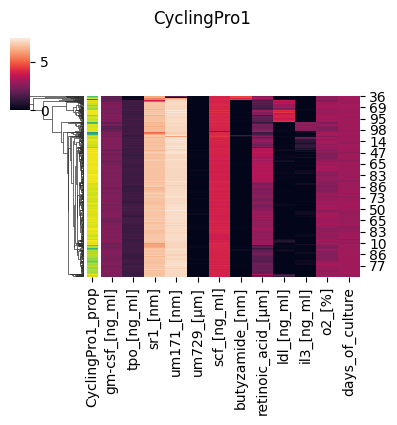

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


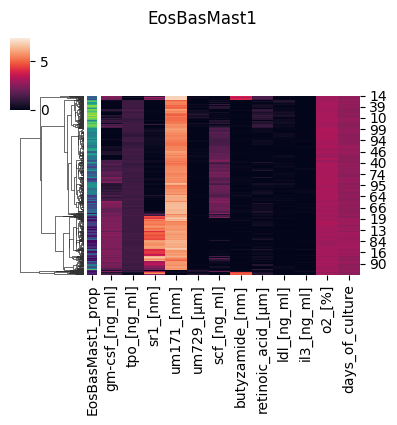

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


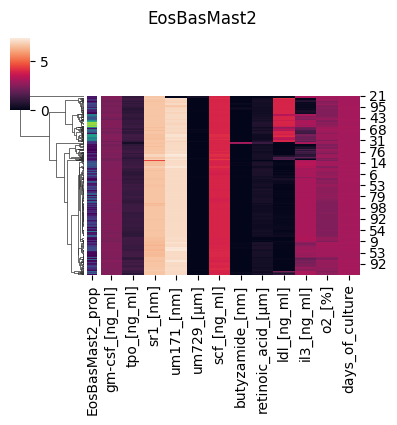

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


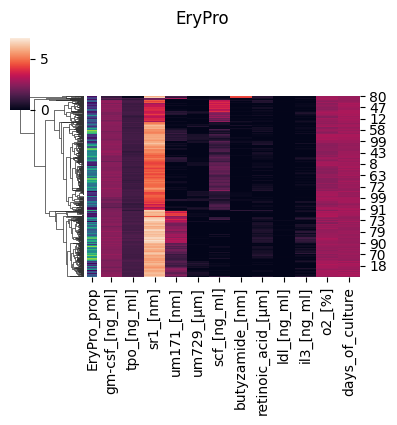

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


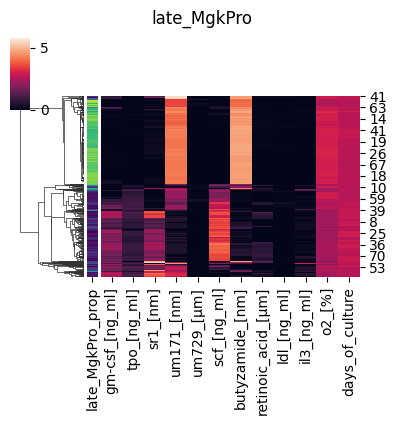

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


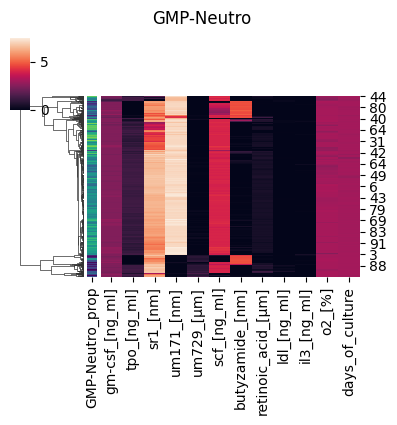

In [24]:
save_dir = "plots/generated_heatmaps"
os.makedirs(save_dir, exist_ok=True)

for cell_type in filtered_df:
    data = np.log1p(filtered_df[cell_type].loc[:, protocol_cols])
    
    # Get the annotation column
    prop_col = filtered_df[cell_type][f"{cell_type}_prop"]
    
    # Normalize + map to colors
    norm = plt.Normalize(prop_col.min(), prop_col.max())
    cmap = plt.cm.viridis
    row_colors = prop_col.map(lambda x: cmap(norm(x)))
    
    g = sns.clustermap(
        data,
        figsize=(4, 4),
        row_cluster=True,
        col_cluster=False,
        row_colors=row_colors
    )
    
    g.fig.suptitle(cell_type, y=1.05)
    
    # Save as SVG with cell type label
    safe_name = cell_type.replace(" ", "_").replace("/", "-")
    g.fig.savefig(f"{save_dir}/{safe_name}.png", format='png', bbox_inches='tight', dpi=500)
    plt.show()

## Check these protocols in the real data 

In [17]:
protocol_adata_real = sc.read_h5ad("protocol_adata.h5ad")[:, 3:]

In [18]:
protocol_adata_real.var.index = protocol_cols

/tmp/ipykernel_2882166/1370802562.py:1: ImplicitModificationWarning: Trying to modify index of attribute `.var` of view, initializing view as actual.
  protocol_adata_real.var.index = protocol_cols


In [20]:
# obs_cell_type.X.shape

CD14Mono


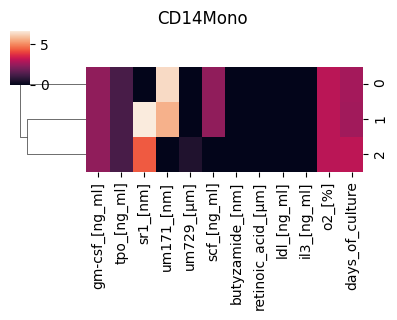

CD16Mono


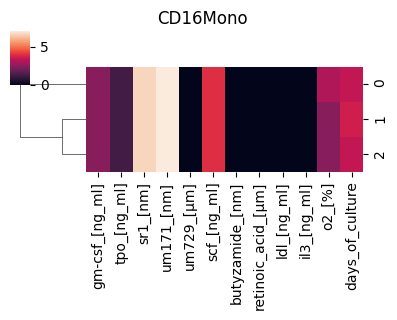

CyclingPro1


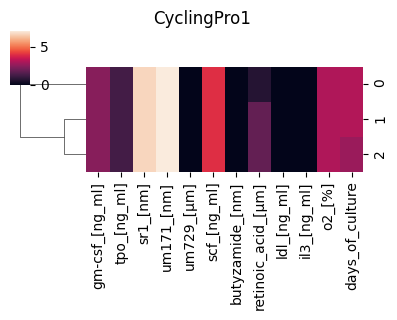

CyclingPro2


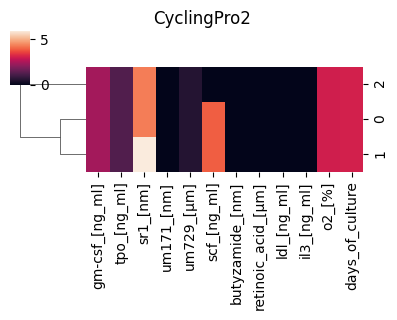

Early_GMP


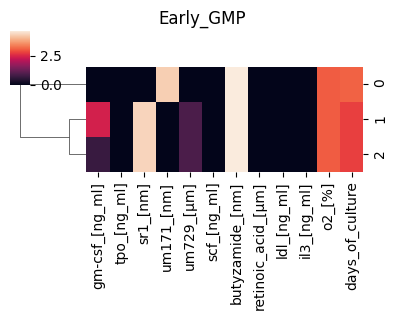

EosBasMast1


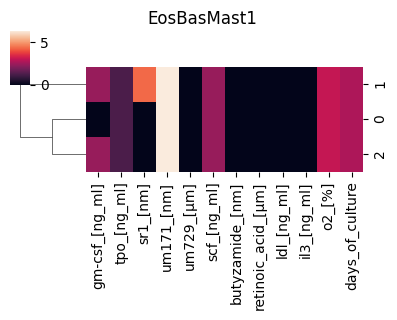

EosBasMast2


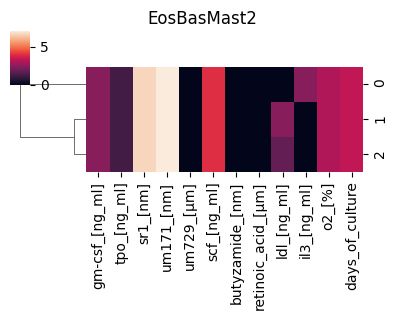

EosBasMast3


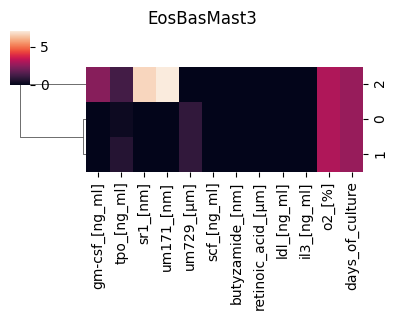

EryPro


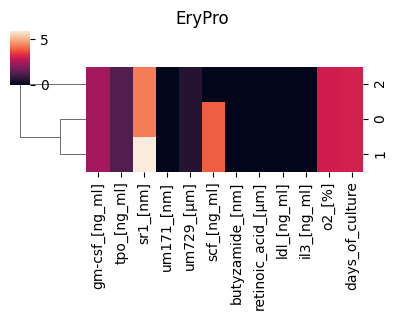

GMP-Neutro


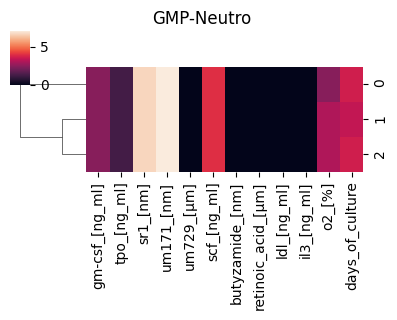

GMP_cycling


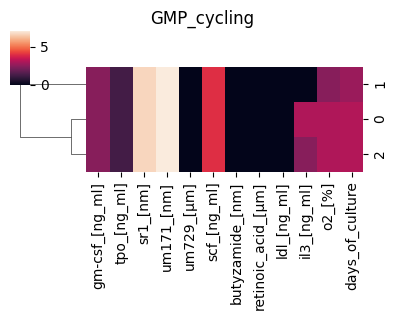

HSCs


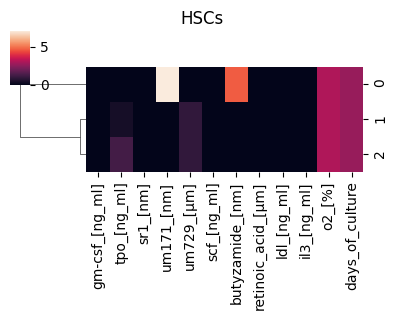

LMPP-CLP


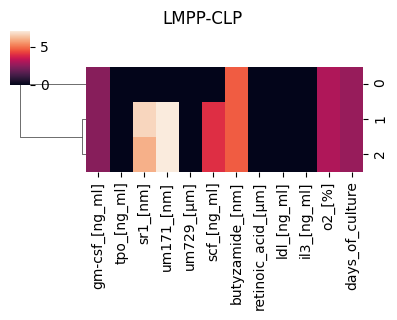

MLP


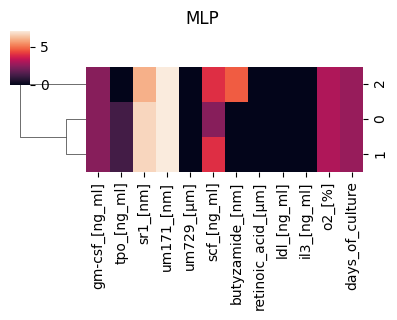

MPP


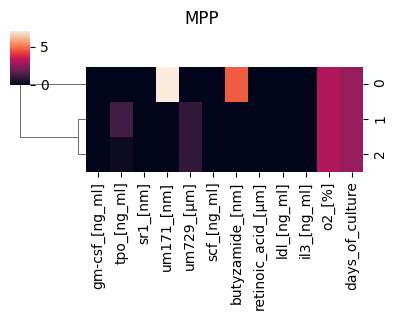

MPP_MgkEry


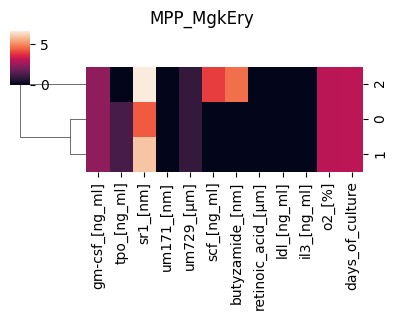

MgKEryPro1


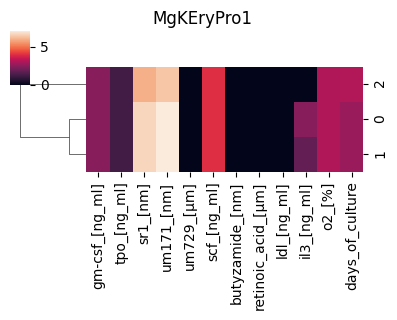

MgKEryPro2


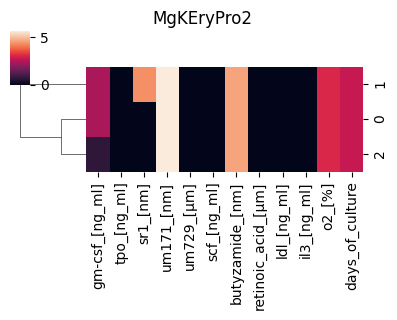

ProB


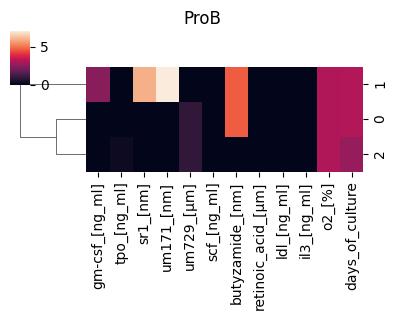

cell_counts


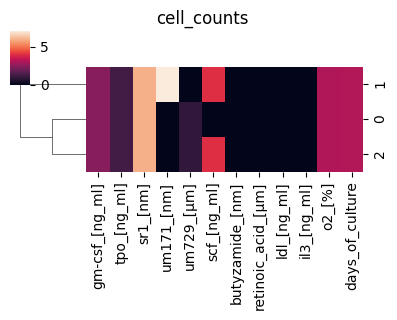

earlyMPP


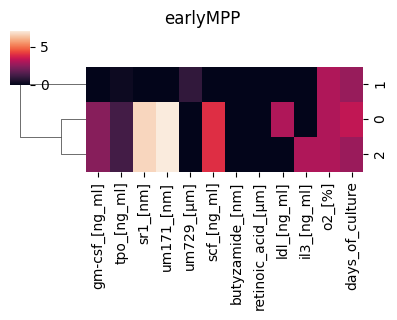

late_MgkPro


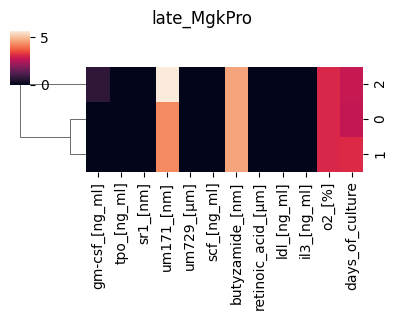

preProB


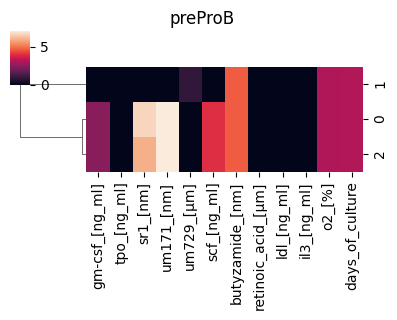

pre_cDC1


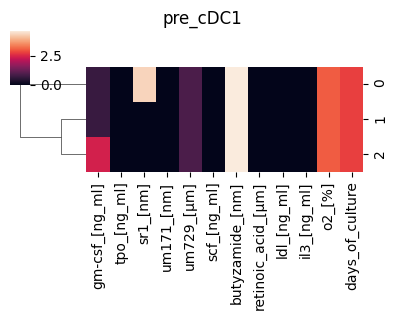

pre_cDC2


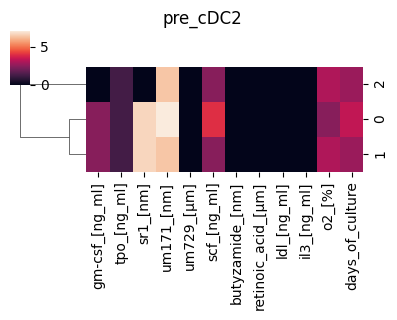

In [32]:
save_dir = "plots/real_heatmaps"
os.makedirs(save_dir, exist_ok=True)

for cell_type in protocol_adata_real.obs.columns:
    if cell_type in ["_index", "experiment_id"]:
        continue
    print(cell_type)
    
    # Get top 10 indices based on highest proportions
    top_idx = protocol_adata_real.obs[cell_type].nlargest(3).index
    
    # Subset using those indices
    obs_cell_type = protocol_adata_real[top_idx]
    
    obs_cell_type_X = pd.DataFrame(
        obs_cell_type.X, 
        columns=obs_cell_type.var.index
    )
    
    g = sns.clustermap(
        obs_cell_type_X,
        figsize=(4, 3),
        row_cluster=True,
        col_cluster=False,
    )
    g.fig.suptitle(cell_type, y=1.05)
    
    # Save as SVG with cell type label and real flag
    safe_name = cell_type.replace(" ", "_").replace("/", "-")
    g.fig.savefig(f"{save_dir}/{safe_name}_real.png", format='png', bbox_inches='tight', dpi=500)
    plt.show()